# ☕ Comparación de Modelos entre Miembros del Equipo
### Clasificación de Calidad de Café

---

## 🗺️ Hoja de Ruta de este Notebook

| Bloque | Qué vamos a hacer |
|--------|-------------------|
| **0** | Importar librerías |
| **1** | Cargar modelos y datos de cada miembro |
| **2** | Calcular métricas comparativas |
| **3** | Tabla comparativa global |
| **4** | Visualización de métricas |
| **5** | Análisis de overfitting |
| **6** | Curvas ROC comparativas |
| **7** | Matrices de confusión |

---

> ⚠️ **Requisito previo:** cada miembro debe haber guardado en su carpeta `models/`  
> los archivos: `model.pkl`, `X_train.pkl`, `X_test.pkl`, `y_train.pkl`, `y_test.pkl`


---
## 📦 BLOQUE 0 — Importar librerías

Las mismas que en los notebooks individuales, más `Path` para gestionar rutas
de forma compatible entre Windows, Mac y Linux.


In [1]:
# ─── Librerías base ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Rutas ────────────────────────────────────────────────────────────────────
from pathlib import Path

# ─── Métricas ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# ─── Guardar / cargar modelos ─────────────────────────────────────────────────
import joblib

# ─── Configuración visual ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

print('✅ Librerías importadas correctamente')


✅ Librerías importadas correctamente


---
## 📂 BLOQUE 1 — Cargar modelos y datos de cada miembro

Cada miembro entrenó su modelo con variables diferentes, por lo que no podemos
reconstruir los datos desde el CSV — cada uno hizo un preprocesamiento distinto.

La solución es que cada miembro guardó sus splits ya procesados junto al modelo:

| Archivo | Contenido |
|---------|-----------|
| `model.pkl` | Modelo entrenado (RF, DT, XGBoost...) |
| `X_train.pkl` | Features de entrenamiento ya preprocesadas |
| `X_test.pkl` | Features de test ya preprocesadas |
| `y_train.pkl` | Target de entrenamiento |
| `y_test.pkl` | Target de test |

> 💡 Así cada modelo se evalúa exactamente con los mismos datos con los que fue entrenado,
> sin riesgo de inconsistencias en el preprocesamiento.


In [3]:
# ─── Rutas a las carpetas de cada miembro ────────────────────────────────────

MIEMBROS = {
    'Jonathan'  : Path('../models/Jonathan'),
    'Camila'  : Path('../models/Camila'),
   # 'Juan'  : Path('../../models/Juanma')
}

# ─── Verificar que existen los archivos necesarios ────────────────────────────
archivos_requeridos = ['model.pkl', 'X_train.pkl', 'X_test.pkl', 'y_train.pkl', 'y_test.pkl']

print('🔍 Verificando archivos de cada miembro:')
for miembro, path in MIEMBROS.items():
    faltantes = [f for f in archivos_requeridos if not (path / f).exists()]
    if faltantes:
        print(f'  ⚠️  {miembro} — Faltan: {faltantes}')
    else:
        print(f'  ✅  {miembro} — Todos los archivos presentes')


🔍 Verificando archivos de cada miembro:
  ✅  Jonathan — Todos los archivos presentes
  ✅  Camila — Todos los archivos presentes


---
## 📊 BLOQUE 2 — Calcular métricas de cada modelo

Para cada miembro calculamos:

| Métrica | Qué mide | Por qué la usamos |
|---------|----------|-------------------|
| **F1 Train** | Rendimiento sobre datos de entrenamiento | Para detectar overfitting |
| **F1 Test** | Rendimiento sobre datos nunca vistos | Métrica principal de comparación |
| **Accuracy** | % predicciones correctas | Visión general |
| **Precision** | De los Specialty predichos, ¿cuántos son reales? | Falsos positivos |
| **Recall** | De todos los Specialty reales, ¿cuántos encontramos? | Falsos negativos |
| **ROC-AUC** | Capacidad de separar clases a todos los umbrales | Evaluación global |
| **CV F1 Media** | F1 promedio en 5 splits distintos | Robustez del modelo |
| **CV F1 Std** | Desviación del CV F1 | Estabilidad del modelo |
| **Overfitting (Δ)** | F1 Train − F1 Test | < 0.05 = modelo sano |

> ⚠️ **Sobre el overfitting:** un modelo que memoriza el train tendrá F1 Train ≈ 1.0
> pero F1 Test mucho menor. Un Δ < 0.05 indica que el modelo generaliza bien.


In [4]:
# ─── Función para evaluar un modelo desde sus archivos .pkl ──────────────────
def evaluar_desde_pkl(miembro, path):
    """
    Carga el modelo y los datos guardados por cada miembro y calcula
    todas las métricas necesarias para la comparación.
    """
    # ─── Cargar artefactos ────────────────────────────────────────────────────
    modelo  = joblib.load(path / 'model.pkl')
    X_train = joblib.load(path / 'X_train.pkl')
    X_test  = joblib.load(path / 'X_test.pkl')
    y_train = joblib.load(path / 'y_train.pkl')
    y_test  = joblib.load(path / 'y_test.pkl')

    # ─── Predicciones ─────────────────────────────────────────────────────────
    y_pred_train = modelo.predict(X_train)
    y_pred_test  = modelo.predict(X_test)
    y_prob_test  = modelo.predict_proba(X_test)[:, 1]

    # ─── Validación cruzada ───────────────────────────────────────────────────
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='f1')

    # ─── Métricas ─────────────────────────────────────────────────────────────
    f1_train = f1_score(y_train, y_pred_train)
    f1_test  = f1_score(y_test,  y_pred_test)

    return {
        # Identificación
        'Miembro'     : miembro,
        'Modelo'      : type(modelo).__name__,
        'Nº Features' : X_train.shape[1],
        # Métricas clave
        'F1 Train'    : round(f1_train, 4),
        'F1 Test'     : round(f1_test,  4),
        'Accuracy'    : round(accuracy_score(y_test, y_pred_test),  4),
        'Precision'   : round(precision_score(y_test, y_pred_test), 4),
        'Recall'      : round(recall_score(y_test, y_pred_test),    4),
        'ROC-AUC'     : round(roc_auc_score(y_test, y_prob_test),   4),
        'CV F1 Media' : round(cv_scores.mean(), 4),
        'CV F1 Std'   : round(cv_scores.std(),  4),
        'Overfitting' : round(f1_train - f1_test, 4),
        # Objetos internos para visualizaciones (se eliminan del DataFrame)
        '_modelo'     : modelo,
        '_X_test'     : X_test,
        '_y_test'     : y_test,
    }

print('✅ Función de evaluación lista')


✅ Función de evaluación lista


In [9]:
# ─── Evaluar todos los modelos ───────────────────────────────────────────────
datos_brutos = []

for miembro, path in MIEMBROS.items():
    print(f'⏳ Evaluando {miembro}...')
    resultado = evaluar_desde_pkl(miembro, path)
    datos_brutos.append(resultado)
    print(f'  ✅ {miembro} — F1 Test: {resultado["F1 Test"]:.4f} | '
          f'CV F1: {resultado["CV F1 Media"]:.4f} ± {resultado["CV F1 Std"]:.4f}')

# ─── Separar objetos internos del DataFrame ───────────────────────────────────
# (los objetos modelo/datos no se pueden poner en un DataFrame de métricas)
objetos = {
    d['Miembro']: (d.pop('_modelo'), d.pop('_X_test'), d.pop('_y_test'))
    for d in datos_brutos
}

print('\n✅ Evaluación completada para todos los miembros')


⏳ Evaluando Jonathan...
  ✅ Jonathan — F1 Test: 0.9477 | CV F1: 0.9354 ± 0.0167
⏳ Evaluando Camila...
  ✅ Camila — F1 Test: 0.9552 | CV F1: 0.9449 ± 0.0048

✅ Evaluación completada para todos los miembros


---
## 📋 BLOQUE 3 — Tabla comparativa global

Reunimos todas las métricas en una sola tabla ordenada por **CV F1 Media**,
que es el criterio más robusto para comparar modelos:

- **F1 en test** puede verse afectado por la suerte del split
- **CV F1 Media** promedia 5 splits distintos — mucho más representativo
- **CV F1 Std** nos dice si el modelo es consistente o variable entre splits


In [10]:
# ─── Construir DataFrame de comparación ──────────────────────────────────────
df_res = pd.DataFrame(datos_brutos)

# ─── Columna de estado de overfitting ────────────────────────────────────────
df_res['Overfitting OK'] = df_res['Overfitting'].apply(
    lambda x: '✅ OK' if abs(x) < 0.05 else '⚠️ Revisar'
)

# ─── Ordenar por CV F1 Media (criterio principal) ────────────────────────────
df_res = df_res.sort_values('CV F1 Media', ascending=False).reset_index(drop=True)
df_res.index += 1  # Ranking desde 1

# ─── Mostrar tabla ────────────────────────────────────────────────────────────
cols_tabla = ['Miembro', 'Modelo', 'Nº Features', 'F1 Train', 'F1 Test',
              'Accuracy', 'Precision', 'Recall', 'ROC-AUC',
              'CV F1 Media', 'CV F1 Std', 'Overfitting', 'Overfitting OK']

print('📊 Comparación de modelos (ordenado por CV F1 Media):')
print(df_res[cols_tabla].to_string())

print(f'\n🥇 Mejor modelo: {df_res.iloc[0]["Miembro"]} — {df_res.iloc[0]["Modelo"]}')
print(f'   CV F1 Media : {df_res.iloc[0]["CV F1 Media"]:.4f} ± {df_res.iloc[0]["CV F1 Std"]:.4f}')
print(f'   F1 Test     : {df_res.iloc[0]["F1 Test"]:.4f}')
print(f'   Overfitting : {df_res.iloc[0]["Overfitting"]:.4f}  {df_res.iloc[0]["Overfitting OK"]}')


📊 Comparación de modelos (ordenado por CV F1 Media):
    Miembro                  Modelo  Nº Features  F1 Train  F1 Test  Accuracy  Precision  Recall  ROC-AUC  CV F1 Media  CV F1 Std  Overfitting Overfitting OK
1    Camila           XGBClassifier           15    0.9874   0.9552    0.9507     0.9302  0.9816   0.9904       0.9449     0.0048       0.0322           ✅ OK
2  Jonathan  RandomForestClassifier           15    0.9623   0.9477    0.9406     0.9209  0.9760   0.9741       0.9354     0.0167       0.0146           ✅ OK

🥇 Mejor modelo: Camila — XGBClassifier
   CV F1 Media : 0.9449 ± 0.0048
   F1 Test     : 0.9552
   Overfitting : 0.0322  ✅ OK


---
## 📊 BLOQUE 4 — Visualización de métricas comparativas

Comparamos visualmente las 6 métricas principales entre los tres modelos.
La línea gris punteada en 0.90 sirve como referencia mínima de calidad.


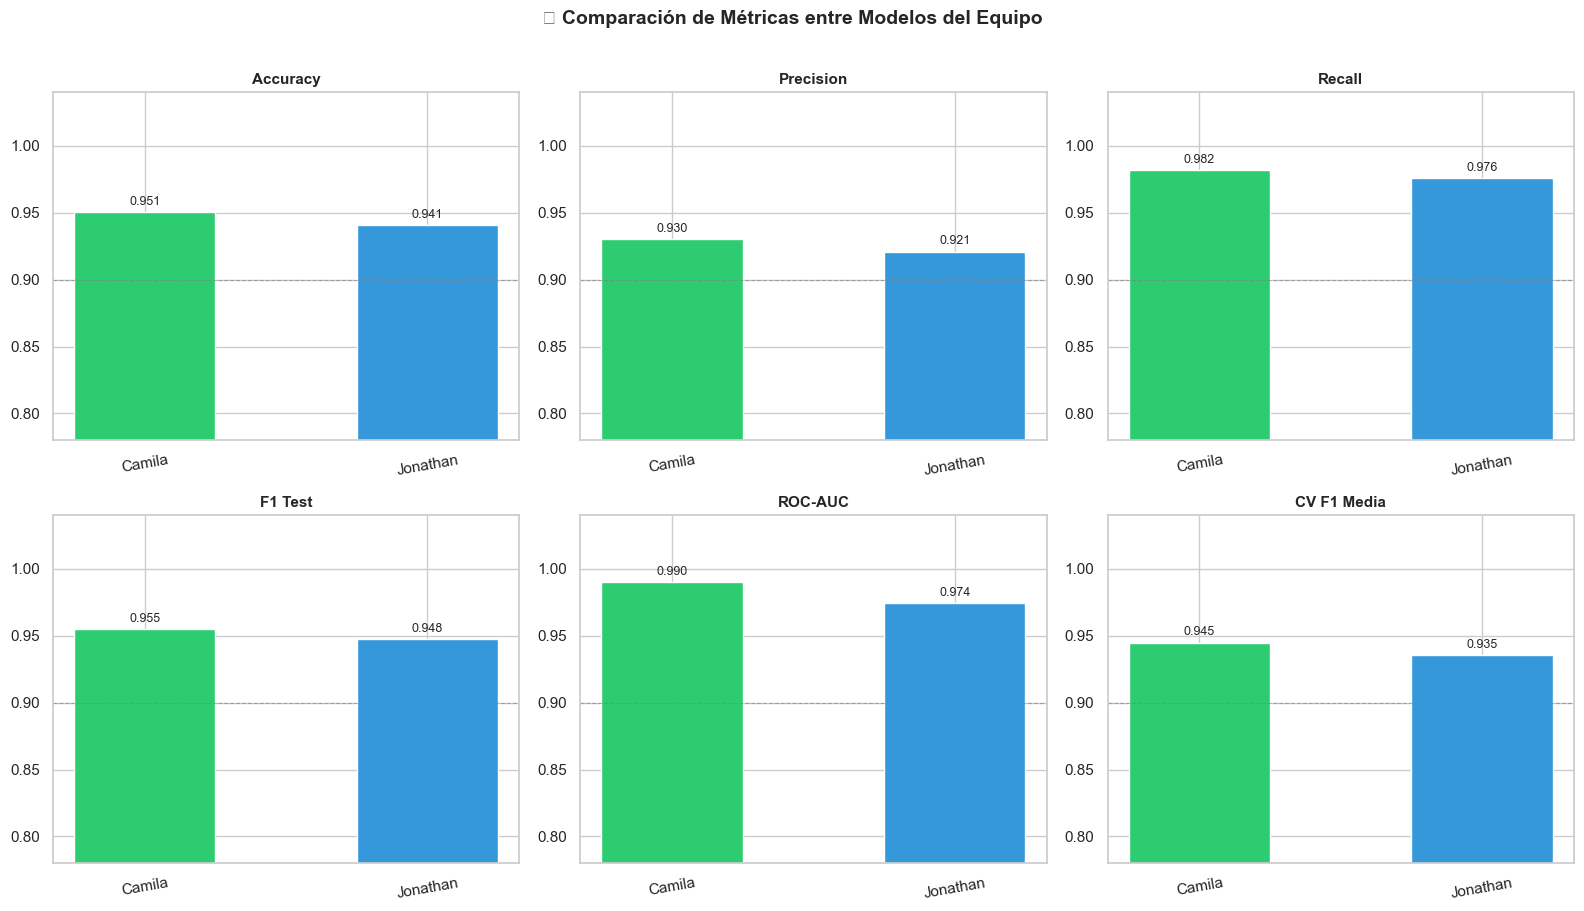

✅ Gráfico de métricas generado


In [11]:
# ─── Paleta de colores por miembro ───────────────────────────────────────────
COLORES = ['#2ecc71', '#3498db', '#e74c3c']
metricas_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Test', 'ROC-AUC', 'CV F1 Media']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, metrica in enumerate(metricas_plot):
    bars = axes[i].bar(
        df_res['Miembro'], df_res[metrica],
        color=COLORES[:len(df_res)], edgecolor='white', width=0.5
    )
    axes[i].set_title(metrica, fontweight='bold', fontsize=11)
    axes[i].set_ylim(0.78, 1.04)
    axes[i].axhline(0.90, color='gray', linestyle='--', linewidth=0.8, alpha=0.6,
                    label='Referencia 0.90')
    axes[i].bar_label(bars, fmt='%.3f', fontsize=9, padding=3)
    axes[i].tick_params(axis='x', rotation=10)
    axes[i].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

fig.suptitle('☕ Comparación de Métricas entre Modelos del Equipo',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('✅ Gráfico de métricas generado')


---
## 🔬 BLOQUE 5 — Análisis de Overfitting

### ¿Qué es el overfitting?

Ocurre cuando un modelo memoriza los datos de entrenamiento en lugar de aprender
patrones generalizables. Se detecta comparando el rendimiento en train vs test:

| Δ (F1 Train − F1 Test) | Diagnóstico |
|------------------------|-------------|
| < 0.02 | Sin overfitting — modelo muy estable |
| 0.02 – 0.05 | Overfitting leve — aceptable |
| > 0.05 | Overfitting significativo — revisar regularización |
| > 0.10 | Overfitting severo — el modelo no generaliza |

> 💡 Un Δ **negativo** (F1 Test > F1 Train) puede indicar que el modelo
> es demasiado conservador en train o que el test fue especialmente fácil.


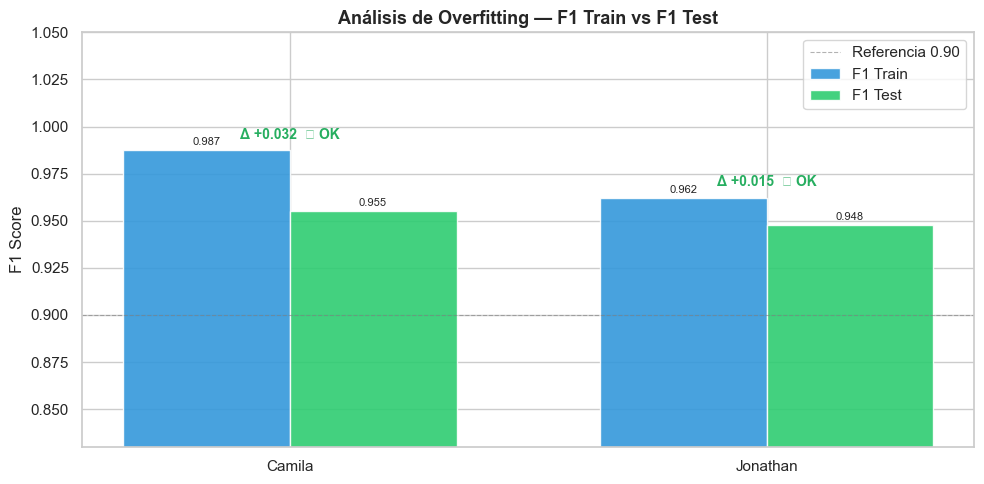


📋 Resumen de overfitting:
  Miembro        Modelo                  F1 Train  F1 Test        Δ  Estado
  ──────────────────────────────────────────────────────────────────────
  Camila         XGBClassifier             0.9874   0.9552  +0.0322  ✅ OK
  Jonathan       RandomForestClassifier    0.9623   0.9477  +0.0146  ✅ OK


In [12]:
# ─── Gráfico de overfitting — F1 Train vs F1 Test ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(df_res))
width = 0.35

bars_train = ax.bar(x - width/2, df_res['F1 Train'], width,
                    label='F1 Train', color='#3498db', edgecolor='white', alpha=0.9)
bars_test  = ax.bar(x + width/2, df_res['F1 Test'],  width,
                    label='F1 Test',  color='#2ecc71', edgecolor='white', alpha=0.9)

# ─── Etiqueta Δ sobre cada par de barras ─────────────────────────────────────
for i, row in df_res.iterrows():
    idx   = i - 1  # i empieza en 1 por el reset_index anterior
    delta = row['Overfitting']
    color = '#e74c3c' if abs(delta) >= 0.05 else '#27ae60'
    ax.annotate(
        f'Δ {delta:+.3f}  {row["Overfitting OK"]}',
        xy=(idx, max(row['F1 Train'], row['F1 Test']) + 0.006),
        ha='center', fontsize=10, color=color, fontweight='bold'
    )

ax.bar_label(bars_train, fmt='%.3f', fontsize=8, padding=2)
ax.bar_label(bars_test,  fmt='%.3f', fontsize=8, padding=2)

ax.axhline(0.90, color='gray', linestyle='--', linewidth=0.8,
           alpha=0.6, label='Referencia 0.90')
ax.set_xticks(x)
ax.set_xticklabels(df_res['Miembro'], fontsize=11)
ax.set_ylim(0.83, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('Análisis de Overfitting — F1 Train vs F1 Test',
             fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# ─── Resumen en texto ─────────────────────────────────────────────────────────
print('\n📋 Resumen de overfitting:')
print(f'  {"Miembro":<14} {"Modelo":<22} {"F1 Train":>9} {"F1 Test":>8} {"Δ":>8}  Estado')
print('  ' + '─' * 70)
for _, row in df_res.iterrows():
    print(f'  {row["Miembro"]:<14} {row["Modelo"]:<22} '
          f'{row["F1 Train"]:>9.4f} {row["F1 Test"]:>8.4f} '
          f'{row["Overfitting"]:>+8.4f}  {row["Overfitting OK"]}')


---
## 📈 BLOQUE 6 — Curvas ROC comparativas

La curva ROC muestra el trade-off entre la tasa de verdaderos positivos (Recall)
y la tasa de falsos positivos a **todos los umbrales posibles**.

| ROC-AUC | Interpretación |
|---------|---------------|
| 1.00 | Modelo perfecto |
| > 0.95 | Excelente |
| 0.90 – 0.95 | Muy bueno |
| 0.80 – 0.90 | Bueno |
| 0.50 | Equivale a tirar una moneda — inútil |

> 💡 Una curva que se acerca más a la esquina superior izquierda es mejor.
> La línea punteada diagonal representa un clasificador aleatorio (AUC = 0.50).


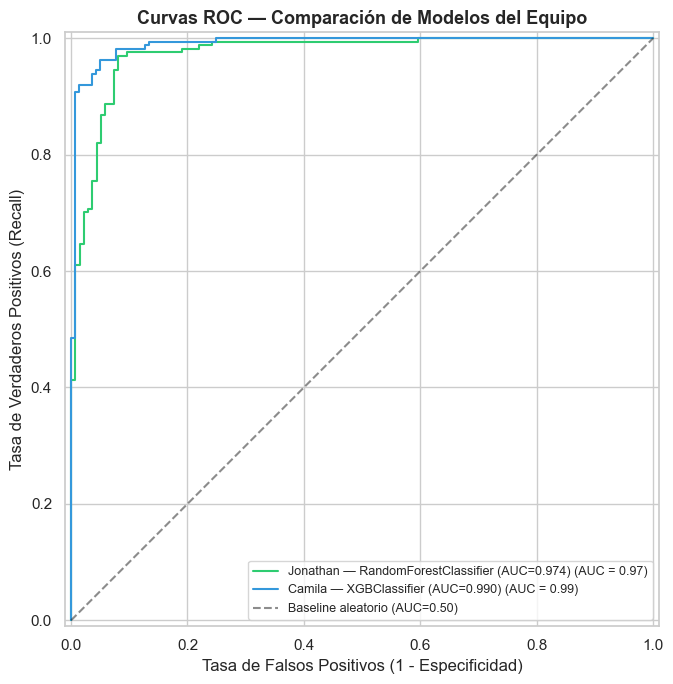

✅ Curvas ROC generadas


In [13]:
# ─── Curvas ROC de todos los modelos en un solo gráfico ─────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

for (miembro, (modelo, X_test, y_test)), color in zip(objetos.items(), COLORES):
    roc_auc = roc_auc_score(y_test, modelo.predict_proba(X_test)[:, 1])
    RocCurveDisplay.from_predictions(
        y_test,
        modelo.predict_proba(X_test)[:, 1],
        name=f'{miembro} — {type(modelo).__name__} (AUC={roc_auc:.3f})',
        color=color,
        ax=ax
    )

ax.plot([0, 1], [0, 1], 'k--', label='Baseline aleatorio (AUC=0.50)', alpha=0.5)
ax.set_title('Curvas ROC — Comparación de Modelos del Equipo',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('✅ Curvas ROC generadas')


---
## 🔢 BLOQUE 7 — Matrices de Confusión

La matriz de confusión desglosa los errores concretos que comete cada modelo:

|  | Predicho No Specialty | Predicho Specialty |
|--|----------------------|--------------------|
| **Real No Specialty** | ✅ Verdadero Negativo (TN) | ❌ Falso Positivo (FP) |
| **Real Specialty** | ❌ Falso Negativo (FN) | ✅ Verdadero Positivo (TP) |

**¿Cuál error es más costoso en este proyecto?**

- **Falso Negativo (FN):** clasificar un café Specialty como No Specialty
  → se vende a precio commodity en lugar de premium → **pérdida económica directa**
- **Falso Positivo (FP):** clasificar un No Specialty como Specialty
  → se manda a certificación oficial innecesariamente → coste menor

Por eso priorizamos **Recall** (minimizar FN) como métrica de negocio clave.


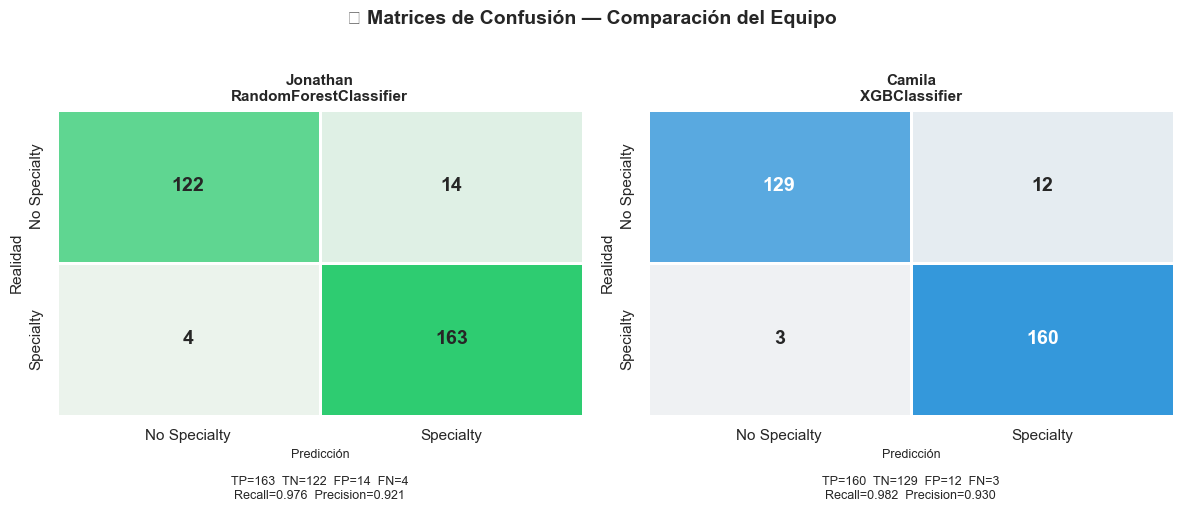

✅ Matrices de confusión generadas


In [14]:
# ─── Matrices de confusión de los 3 modelos en paralelo ─────────────────────
miembros_lista = list(objetos.keys())
n = len(miembros_lista)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
if n == 1:
    axes = [axes]

for ax, (miembro, (modelo, X_test, y_test)), color in zip(axes, objetos.items(), COLORES):
    y_pred = modelo.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap=sns.light_palette(color, as_cmap=True),
        xticklabels=['No Specialty', 'Specialty'],
        yticklabels=['No Specialty', 'Specialty'],
        linewidths=2, linecolor='white',
        ax=ax, cbar=False,
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Realidad', fontsize=11)
    ax.set_title(f'{miembro}\n{type(modelo).__name__}', fontweight='bold', fontsize=11)

    # ─── Resumen bajo el gráfico ──────────────────────────────────────────────
    recall_val    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    ax.set_xlabel(
        f'Predicción\n\nTP={tp}  TN={tn}  FP={fp}  FN={fn}\n'
        f'Recall={recall_val:.3f}  Precision={precision_val:.3f}',
        fontsize=9
    )

fig.suptitle('☕ Matrices de Confusión — Comparación del Equipo',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('✅ Matrices de confusión generadas')


---
## 🏆 BLOQUE 8 — Conclusión y modelo recomendado para el Streamlit

### Criterio de selección

Usamos **CV F1 Media** como criterio principal porque es más robusto que el F1 en test
(promedia 5 splits distintos, no depende de la suerte de un solo split).

En caso de empate en CV F1 Media, el desempate es:
1. **CV F1 Std menor** → modelo más estable
2. **Overfitting menor** → modelo que generaliza mejor
3. **Recall mayor** → prioridad de negocio (detectar Specialty reales)

### Para el Streamlit con 2 modelos

Se seleccionan los **2 modelos con mayor CV F1 Media**.
Si sus features son distintas, el Streamlit mostrará la unión de todos los inputs
y filtrará las columnas correctas antes de hacer `predict()` en cada modelo.


In [15]:
# ─── Selección de los 2 modelos para el Streamlit ────────────────────────────
top2 = df_res.head(2)

print('=' * 60)
print('🏆 MODELOS SELECCIONADOS PARA EL STREAMLIT')
print('=' * 60)

for rank, (_, row) in enumerate(top2.iterrows(), 1):
    print(f'\n  #{rank} — {row["Miembro"]} ({row["Modelo"]})')
    print(f'     CV F1 Media  : {row["CV F1 Media"]:.4f} ± {row["CV F1 Std"]:.4f}')
    print(f'     F1 Test      : {row["F1 Test"]:.4f}')
    print(f'     ROC-AUC      : {row["ROC-AUC"]:.4f}')
    print(f'     Recall       : {row["Recall"]:.4f}')
    print(f'     Overfitting  : {row["Overfitting"]:+.4f}  {row["Overfitting OK"]}')
    print(f'     Nº Features  : {row["Nº Features"]}')

print('\n' + '=' * 60)

# ─── Tabla resumen final ──────────────────────────────────────────────────────
print('\n📋 Tabla resumen completa (ordenada por CV F1 Media):')
cols_resumen = ['Miembro', 'Modelo', 'F1 Test', 'ROC-AUC',
                'CV F1 Media', 'CV F1 Std', 'Overfitting', 'Overfitting OK']
print(df_res[cols_resumen].to_string(index=True))


🏆 MODELOS SELECCIONADOS PARA EL STREAMLIT

  #1 — Camila (XGBClassifier)
     CV F1 Media  : 0.9449 ± 0.0048
     F1 Test      : 0.9552
     ROC-AUC      : 0.9904
     Recall       : 0.9816
     Overfitting  : +0.0322  ✅ OK
     Nº Features  : 15

  #2 — Jonathan (RandomForestClassifier)
     CV F1 Media  : 0.9354 ± 0.0167
     F1 Test      : 0.9477
     ROC-AUC      : 0.9741
     Recall       : 0.9760
     Overfitting  : +0.0146  ✅ OK
     Nº Features  : 15


📋 Tabla resumen completa (ordenada por CV F1 Media):
    Miembro                  Modelo  F1 Test  ROC-AUC  CV F1 Media  CV F1 Std  Overfitting Overfitting OK
1    Camila           XGBClassifier   0.9552   0.9904       0.9449     0.0048       0.0322           ✅ OK
2  Jonathan  RandomForestClassifier   0.9477   0.9741       0.9354     0.0167       0.0146           ✅ OK
